Each record in the database describes a Boston suburb or town. The data was drawn from the Boston Standard Metropolitan Statistical Area (SMSA) in 1970. The attributes are deﬁned as follows (taken from the UCI Machine Learning Repository):

CRIM - per capita crime rate by town

ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS - proportion of non-retail business acres per town.

CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX - nitric oxides concentration (parts per 10 million)

RM - average number of rooms per dwelling

AGE - proportion of owner-occupied units built prior to 1940

DIS - weighted distances to five Boston employment centres

RAD - index of accessibility to radial highways

TAX - full-value property-tax rate per $10,000

PTRATIO - pupil-teacher ratio by town

B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

LSTAT - % lower status of the population

MEDV - Median value of owner-occupied homes in $1000's

Link da competição:

https://www.kaggle.com/account/login?returnUrl=%2Ft%2F7e23527da89b49e1a1b8e62efc4528a1

#Dependencias

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import pearsonr
import seaborn as sns

In [6]:
test = pd.read_csv('test.csv')

In [7]:
train = pd.read_csv('train.csv')

#EDA

Por questões éticas a coluna Black será excluida

In [8]:
train.drop('black',inplace=True,axis=1)

In [9]:
list(train.columns)

['ID',
 'crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'lstat',
 'medv']

In [10]:
train.isna().sum()

ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
lstat      0
medv       0
dtype: int64

In [11]:
train.corr()['medv'].sort_values()

lstat     -0.738600
ptratio   -0.481376
indus     -0.473932
tax       -0.448078
nox       -0.413054
crim      -0.407454
age       -0.358888
rad       -0.352251
ID        -0.221694
chas       0.204390
dis        0.249422
zn         0.344842
rm         0.689598
medv       1.000000
Name: medv, dtype: float64

lstat     -0.738600

rm         0.689598

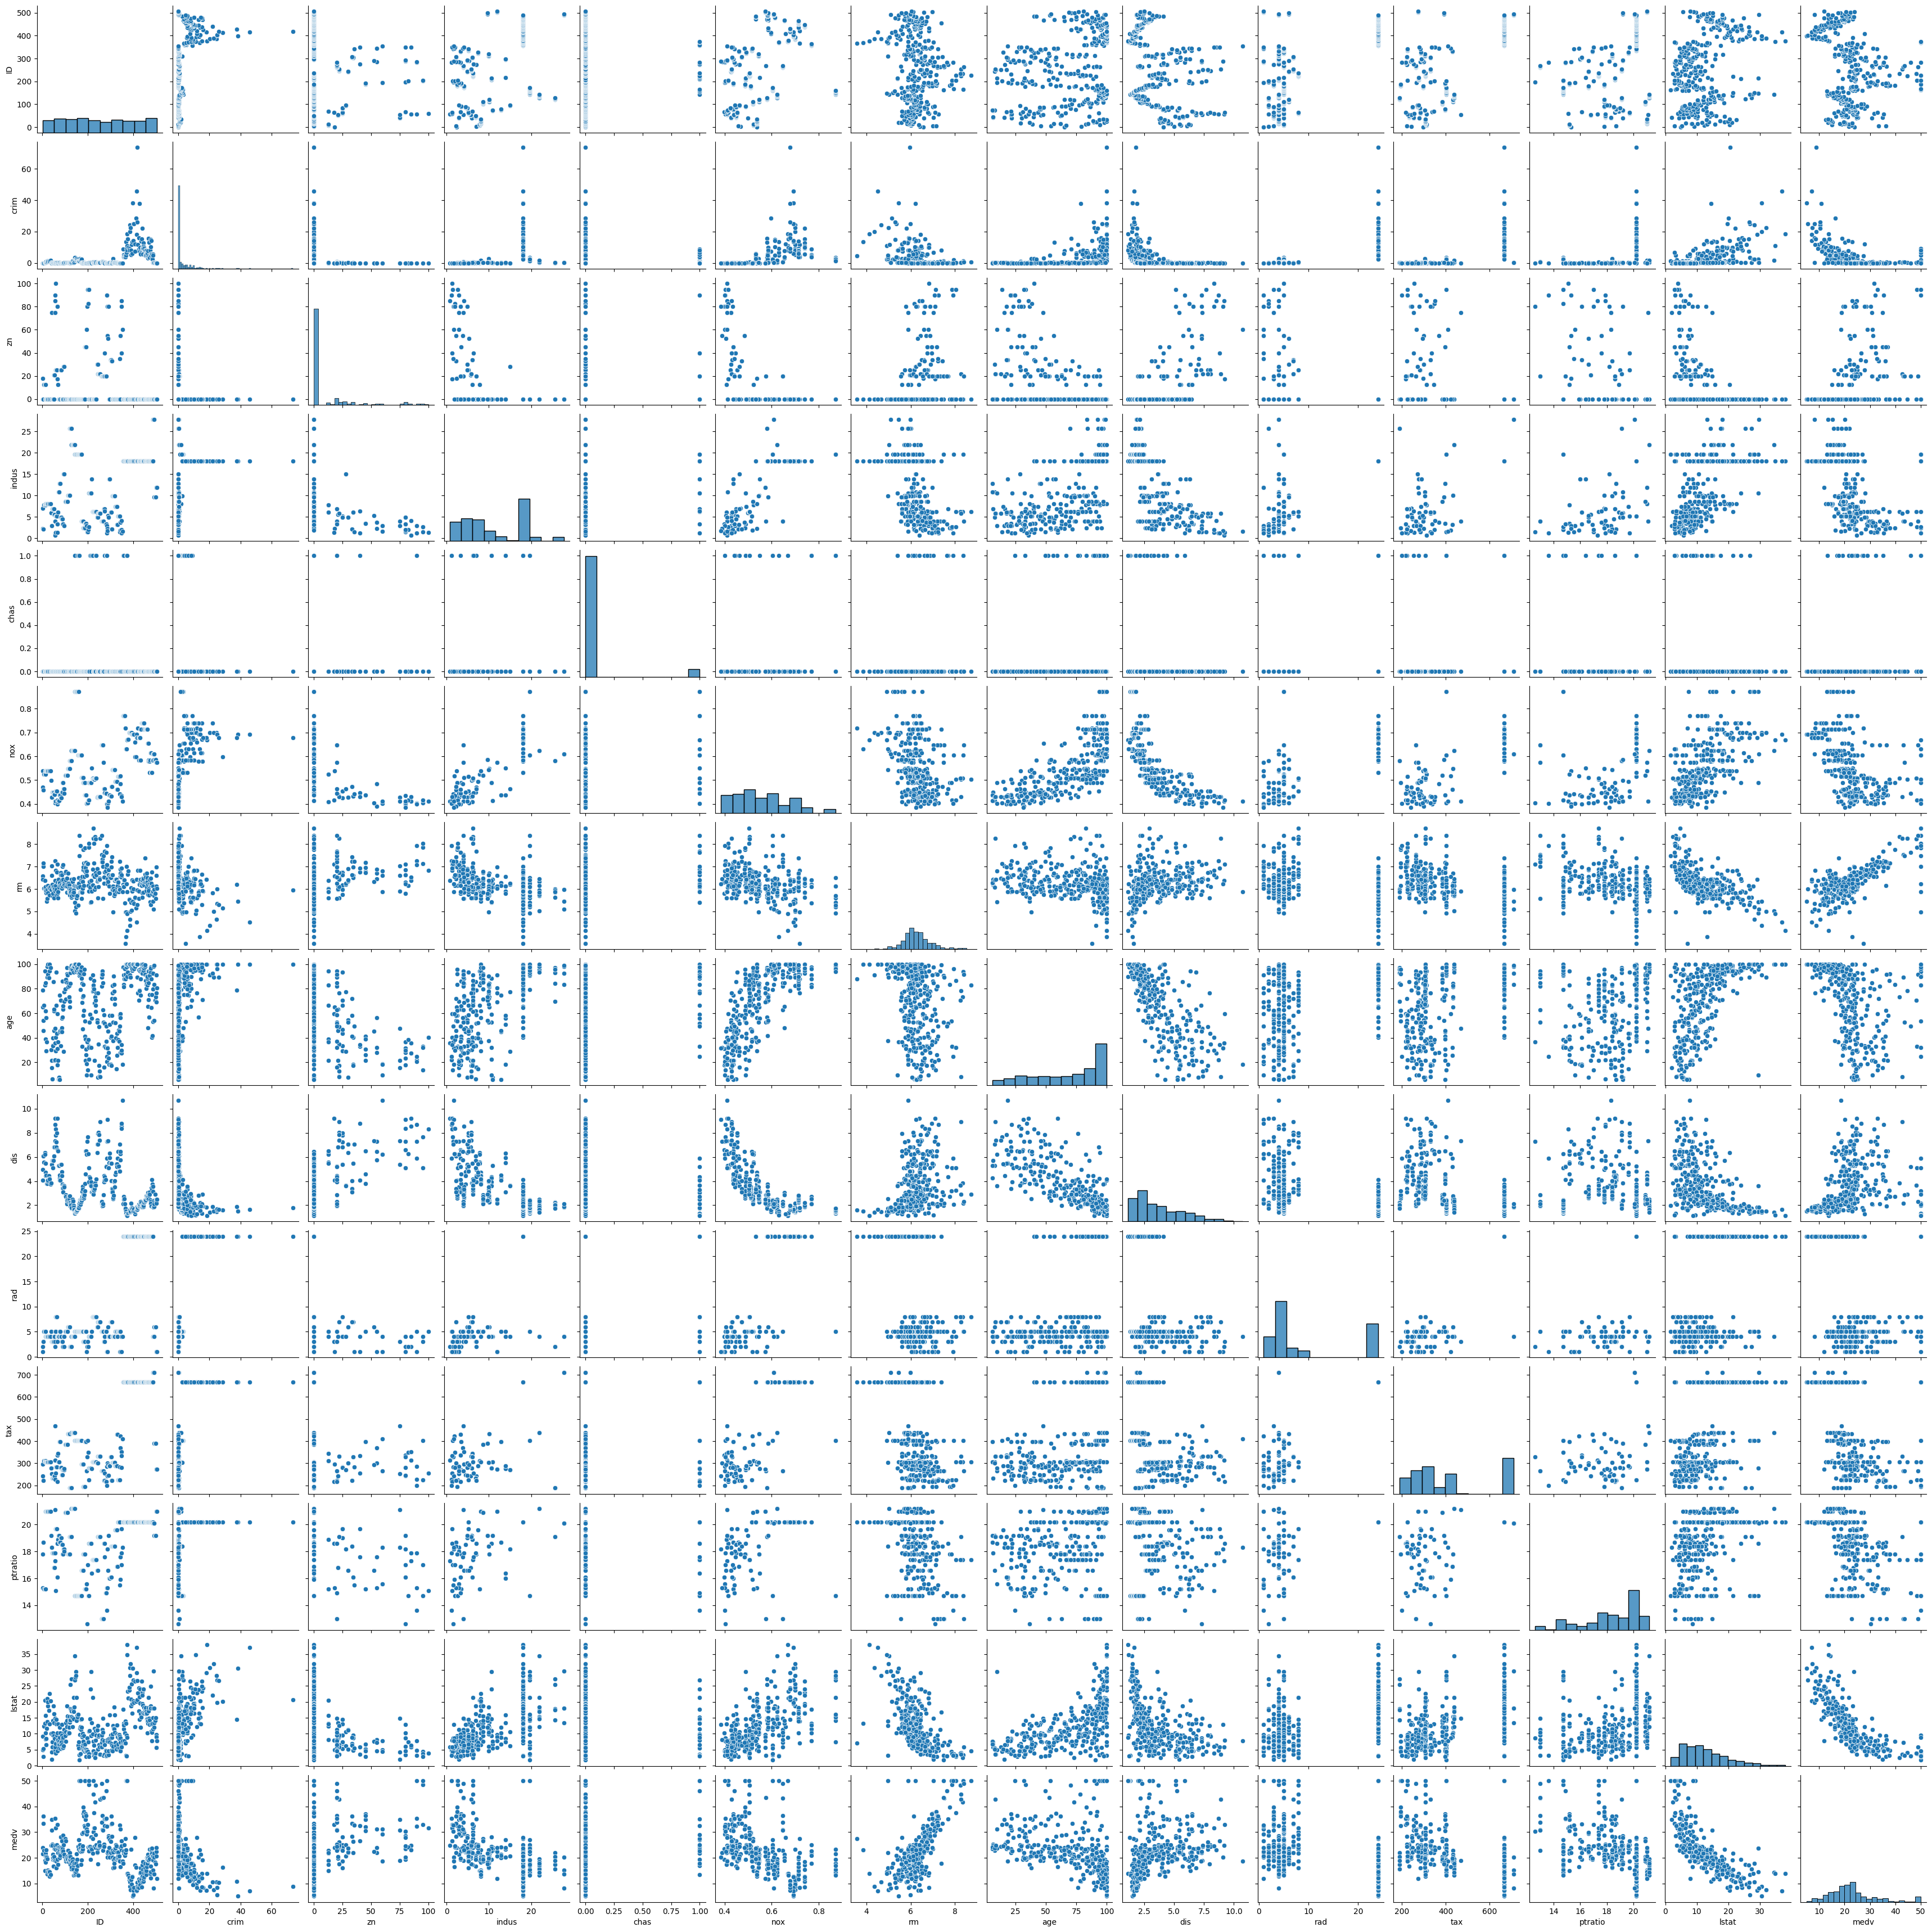

In [12]:
sns.pairplot(train,vars=list(train.columns))

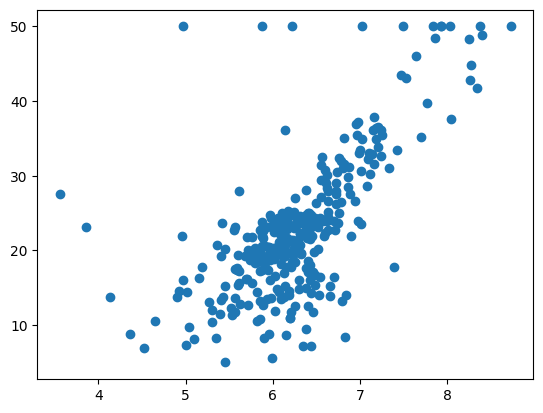

In [13]:
plt.scatter(x=train.rm,y=train.medv)

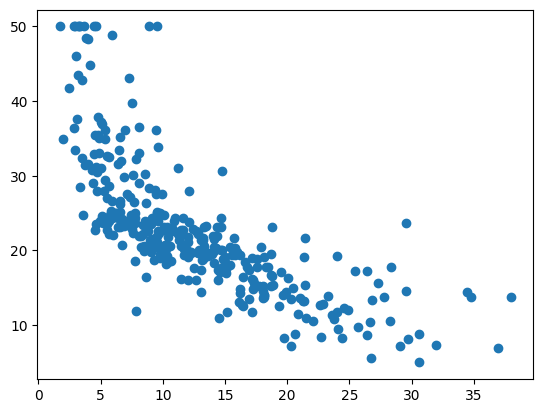

In [14]:
plt.scatter(x=train.lstat,y=train.medv)

In [15]:
endog = 'medv'
exog = 'lstat'
exog2 = 'rm'

In [16]:
analise_sample = train.sample(frac=0.7)

In [17]:
validacao_train = train.sample(frac=0.3)

#Simple Linear Regressions

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

b0: [25.4722544] b1: [[-0.56906103]]


Text(0, 0.5, 'lstat')

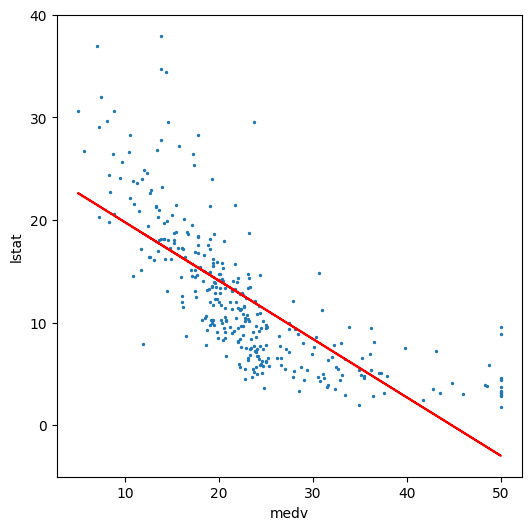

In [19]:
x = train[endog].values.reshape(-1, 1)
y = train[exog].values.reshape(-1, 1)

reg = LinearRegression()
reg.fit(x, y)

print('b0: {} b1: {}'.format(reg.intercept_, reg.coef_))

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=2)
plt.plot(x, reg.predict(x), c='red')
plt.xlabel(endog)
plt.ylabel(exog)

In [20]:
y_pred = reg.predict(x)
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.5455300115227188


b0: [5.06073575] b1: [[0.05291823]]


Text(0, 0.5, 'rm')

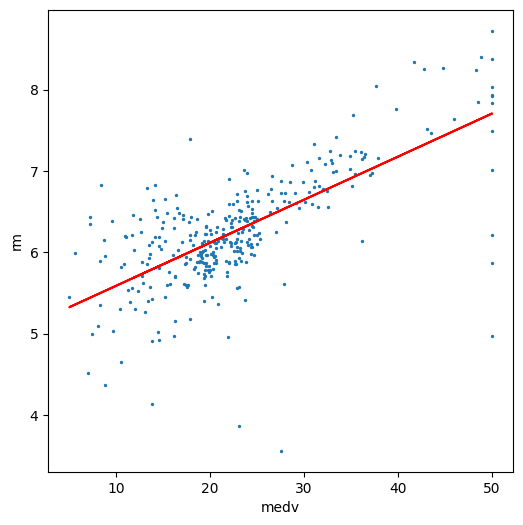

In [21]:
x = train[endog].values.reshape(-1, 1)
y = train[exog2].values.reshape(-1, 1)

reg = LinearRegression()
reg.fit(x, y)

print('b0: {} b1: {}'.format(reg.intercept_, reg.coef_))

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=2)
plt.plot(x, reg.predict(x), c='red')
plt.xlabel(endog)
plt.ylabel(exog2)

In [22]:
y_pred = reg.predict(x)
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.4755455247485778


#Regressão Polinomial

##Bivariavel

In [23]:
class PolynomialRegression():
    def __init__(self, degree=2):
        self.degree = degree
        self.b = None

    def fit(self, x, y):
        powers = self.__compute_powers(x)

        b1 = np.linalg.inv(np.dot(powers.T, powers))
        b2 = np.dot(powers.T, y)
        self.b = np.dot(b1, b2)

    def predict(self, x):
        powers = self.__compute_powers(x)
        return np.dot(powers, self.b)

    def __compute_powers(self, x):
        x = x.ravel()
        powers = np.empty((x.shape[0], self.degree + 1))
        powers[:, 0] = np.ones(x.shape[0])
        powers[:, 1] = x

        for p in range(2, self.degree+1):
            powers[:, p] = x**p
        return powers

###LSTAT

####Quadratica 'lstat'

In [24]:
data = train[['medv','lstat','rm']]

target = 'medv'

features = 'lstat'

In [25]:
x = data[features].values.reshape(-1,1)
y = data[target].values.reshape(-1,1)

In [26]:
reg = PolynomialRegression()
reg.fit(x, y)

print(reg.b)

[[ 4.29848546e+01]
 [-2.31819920e+00]
 [ 4.26138442e-02]]


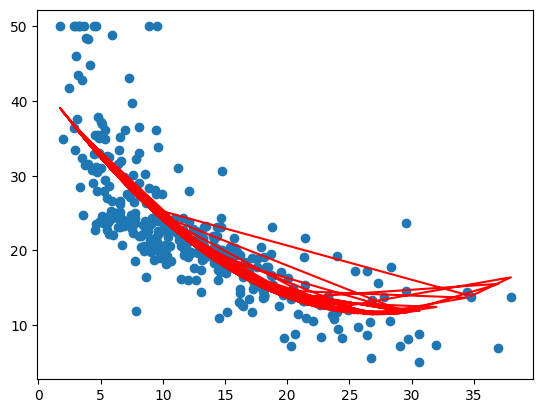

In [27]:
y_pred = reg.predict(x)

plt.scatter(x, y)
plt.plot(x, y_pred, color='red')

In [28]:
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.6406092350877919


####Cubica 'lstat'

[[ 4.81520242e+01]
 [-3.67030347e+00]
 [ 1.34544551e-01]
 [-1.73108358e-03]]


Text(0, 0.5, 'features')

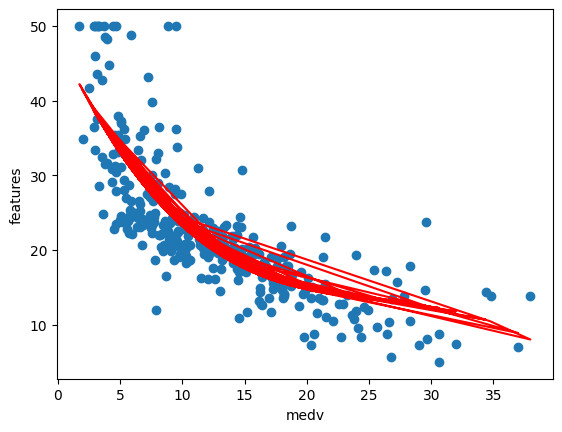

In [29]:
reg = PolynomialRegression(degree=3)
reg.fit(x, y)

print(reg.b)

y_pred = reg.predict(x)
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.xlabel(target)
plt.ylabel('features')

In [30]:
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.6550360077844646


####Quintupla 'lstat'

[[ 6.50379970e+01]
 [-1.09461473e+01]
 [ 1.15158143e+00]
 [-6.23191475e-02]
 [ 1.59570462e-03]
 [-1.52717757e-05]]


Text(0, 0.5, 'features')

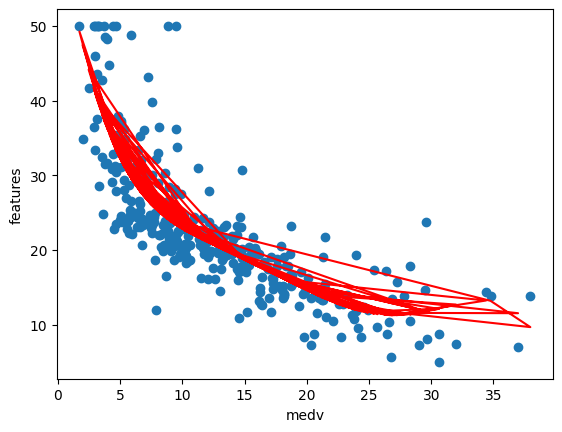

In [31]:
reg = PolynomialRegression(degree=5)
reg.fit(x, y)

print(reg.b)

y_pred = reg.predict(x)
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.xlabel(target)
plt.ylabel('features')

In [32]:
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.6738019186768229


###RM

####Quadratica 'rm'

In [33]:
features = 'rm'

In [34]:
x = data[features].values.reshape(-1,1)
y = data[target].values.reshape(-1,1)

In [35]:
reg = PolynomialRegression()
reg.fit(x, y)

print(reg.b)

[[ 82.02380088]
 [-27.7822401 ]
 [  2.88835238]]


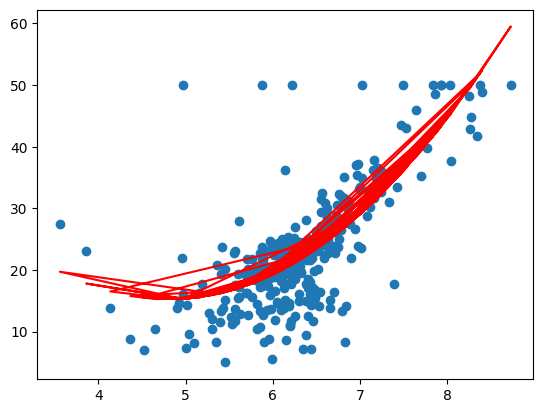

In [36]:
y_pred = reg.predict(x)

plt.scatter(x, y)
plt.plot(x, y_pred, color='red')

In [37]:
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.5707669810622769


####Cubica 'rm'

[[192.91918389]
 [-83.56959149]
 [ 12.03250866]
 [ -0.48892434]]


Text(0, 0.5, 'features')

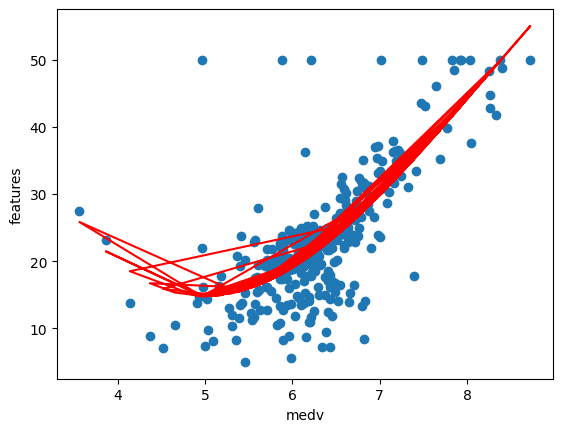

In [38]:
reg = PolynomialRegression(degree=3)
reg.fit(x, y)

print(reg.b)

y_pred = reg.predict(x)
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.xlabel(target)
plt.ylabel('features')

In [39]:
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.5764810673988707


####Quintupla 'rm'

[[ 2.45100805e+03]
 [-2.12540864e+03]
 [ 7.34015701e+02]
 [-1.25480420e+02]
 [ 1.06090552e+01]
 [-3.53588923e-01]]


Text(0, 0.5, 'features')

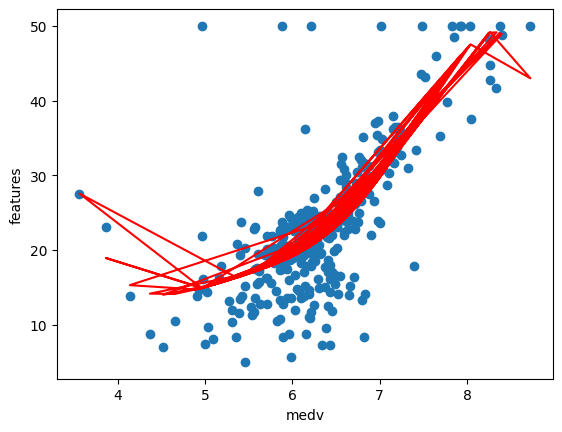

In [40]:
reg = PolynomialRegression(degree=5)
reg.fit(x, y)

print(reg.b)

y_pred = reg.predict(x)
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.xlabel(target)
plt.ylabel('features')

In [41]:
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.5892140371728336


#Robust Model

In [42]:
from scipy.stats import linregress
col_feature = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad',
       'tax', 'ptratio', 'lstat']
for i in col_feature:
  if linregress(train[i], train['medv']).pvalue < 0.02:
    print(linregress(train[i], train['medv']).pvalue)
    print(i)
  else:
    print('fodase',i)

9.476289281606356e-15
crim
9.891559793010909e-11
zn
4.7538159701519275e-20
indus
0.00017302155596403114
chas
3.7482029140195555e-15
nox
2.590093831304518e-48
rm
1.4715158338194666e-11
age
4.076626210078811e-06
dis
3.6634698651847944e-11
rad
7.536200093077821e-18
tax
1.0190852751793793e-20
ptratio
1.2283469073775402e-58
lstat


In [43]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import make_scorer
from sklearn.preprocessing import RobustScaler

In [44]:
def performance_metric(y_true, y_predict):
    score = r2_score(y_true, y_predict)
    return score
scoring_fnc = make_scorer(performance_metric)

In [45]:
train.corr()['medv'].sort_values()

lstat     -0.738600
ptratio   -0.481376
indus     -0.473932
tax       -0.448078
nox       -0.413054
crim      -0.407454
age       -0.358888
rad       -0.352251
ID        -0.221694
chas       0.204390
dis        0.249422
zn         0.344842
rm         0.689598
medv       1.000000
Name: medv, dtype: float64

In [46]:
data = train.copy()

target = 'medv'

features = [
    'lstat',
    'ptratio',
    # 'indus',
    'tax',
    'nox',
    # 'crim',
    'age',
    # 'rad',
    # 'chas',
    # 'dis',
    # 'zn',
    'rm',
    ]
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('polynomial',PolynomialFeatures(3)),
    ('regressor', Ridge()),

])

param_grid = {
    'scaler' : [RobustScaler(),StandardScaler(),MinMaxScaler()],
    'regressor': [
                  # LinearRegression(),
                  Ridge(max_iter=1000),
                  Lasso(max_iter=1000),
                  ],
     'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0 ,100,1000]
}

cv_sets = ShuffleSplit(n_splits = 20, test_size = 0.2, random_state = 0)

grid_search = GridSearchCV(pipeline, param_grid, scoring=scoring_fnc, cv=cv_sets)
grid_search.fit(X_train, y_train)

pipeline.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Melhor modelo: {best_model.named_steps['regressor']}")
print(f"Melhor normalizador: {best_model.named_steps['scaler']}")

y_pred = best_model.predict(X_test)
y_pred = y_pred.astype(int)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('Features:\n',features)
print(f"RMSE do melhor modelo: \n{rmse}")
r2 = r2_score(y_test,y_pred)
print('R2: \n',r2)
print('real:', y_test.values, ' \npred:', y_pred)

/home/mnunes/Estudos/EDAs/env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.697e+02, tolerance: 1.479e+00
  model = cd_fast.enet_coordinate_descent(
/home/mnunes/Estudos/EDAs/env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.627e+02, tolerance: 1.560e+00
  model = cd_fast.enet_coordinate_descent(
/home/mnunes/Estudos/EDAs/env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing 

Melhor modelo: Ridge(alpha=0.01, max_iter=1000)
Melhor normalizador: MinMaxScaler()
Features:
 ['lstat', 'ptratio', 'tax', 'nox', 'age', 'rm']
RMSE do melhor modelo: 
3.0747357610045127
R2: 
 0.8766523612631321
real: [24.7 19.6 19.8 27.9 23.9 13.5 11.7 30.7 17.8 27.1 22.8 18.2 20.6 39.8
 27.9 34.9 23.8 19.3 18.5 10.9 50.  29.1 21.4 22.  15.  50.   5.   8.1
 25.1 15.2 24.3 19.5 22.6 17.3 14.1 10.8 25.2  8.8 17.4 23.1 23.4 33.
 24.8 43.5 50.  20.4  8.3 22.  15.4 16.7 13.3 31.2 22.2 14.5 27.  13.8
 21.7 23.9 28.1 22.8 14.9 23.  14.3 36.2 21.2 13.8 22.2 19.  19.2 14.1
 14.8 25.3 13.3 20.1 25.  31.  20.3 22.7 22.6 27.5 17.4 24.1 48.8 18.4
 12.   9.7 19.7 17.7 32.4 17.6 17.8 20.6 24.4 22.5 23.6 15.2 18.9 19.4
 17.1 19.4]  
pred: [25 25 21 26 24 16 19 32 18 25 24 18 18 41 28 30 20 15 22 20 38 29 24 24
 20 44  8  8 25 17 21 20 24 18 14  9 25  7 17 17 23 29 26 43 40 19 10 19
 15 16 14 30 24 13 26 10 23 23 25 25 17 23 17 32 21 19 22 21 21 14 15 25
 12 22 31 36 20 20 22 26 18 22 52 17 13  9 21 20

#Predict

In [47]:
final_predict = test[['ID']]

In [48]:
model_test = test[features]

In [49]:
result = best_model.predict(model_test)
result = result.astype(int)

In [50]:
final_predict = final_predict.assign(medv=list(result))

In [51]:
final_predict = final_predict.set_index('ID')

In [52]:
final_predict

,medv
ID,
3,33
6,25
8,19
9,17
10,20
...,...
496,22
497,16
499,20


In [53]:
#final_predict.to_csv('output.csv', encoding = 'utf-8-sig')
#files.download('output.csv')